## Reusable contour styles

Instead of repeating styling arguments on every `contour()` call you can
encapsulate them in an `ekp.styles.Contour` object and reuse it across
different maps and domains.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

data = ekd.from_source("sample", "era5-2t-msl-1985122512.grib").to_fieldlist()
pressure = data.sel({"parameter.variable": "msl"})
temperature = data.sel({"parameter.variable": "2t"})

### Creating a `Contour` style

`ekp.styles.Contour` accepts the same arguments as `Map.contour` –
`units`, `levels`, `colors`, `linewidths`, `linestyles` and `labels`.

In [2]:
msl_style = ekp.styles.Contour(
    units="hPa",
    levels={"step": 4, "reference": 1000},
    colors="plasma",
    linewidths=1,
    labels=True,
)

Pass the style object to `Map.contour` via the `style` argument:

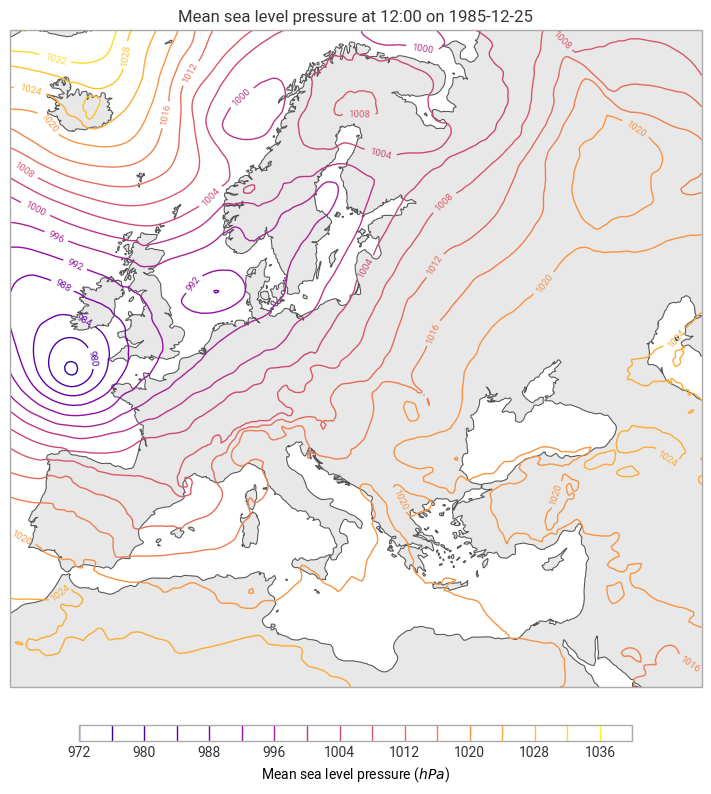

In [3]:
chart = ekp.Map(domain="Europe")
chart.contour(pressure, style=msl_style)
chart.legend()
chart.land()
chart.coastlines()
chart.title()
chart.show()

### Reusing the style on a different domain

Because the style is a plain Python object you can apply it anywhere:

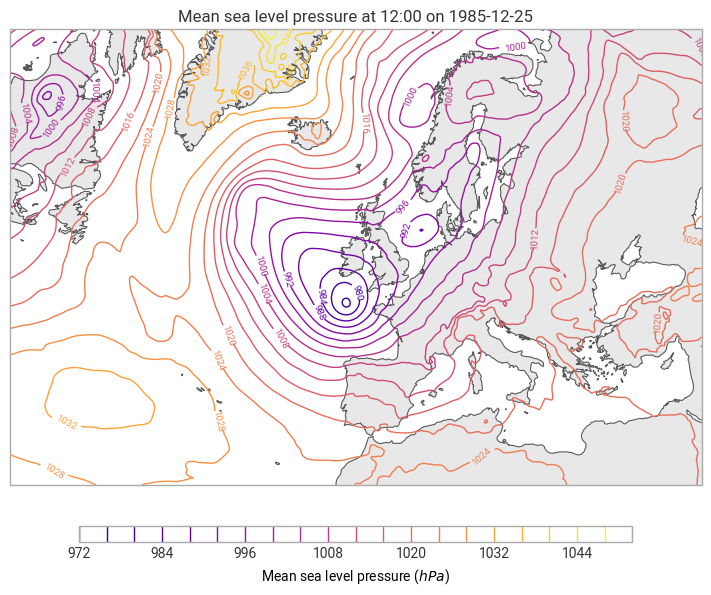

In [4]:
chart = ekp.Map(domain="North Atlantic")
chart.contour(pressure, style=msl_style)
chart.legend()
chart.land()
chart.coastlines()
chart.title()
chart.show()

### Using a colour map vs a single colour

Pass a named matplotlib colour map to `colors` to tint each line by its
value.  Pass a plain colour name for uniform lines.

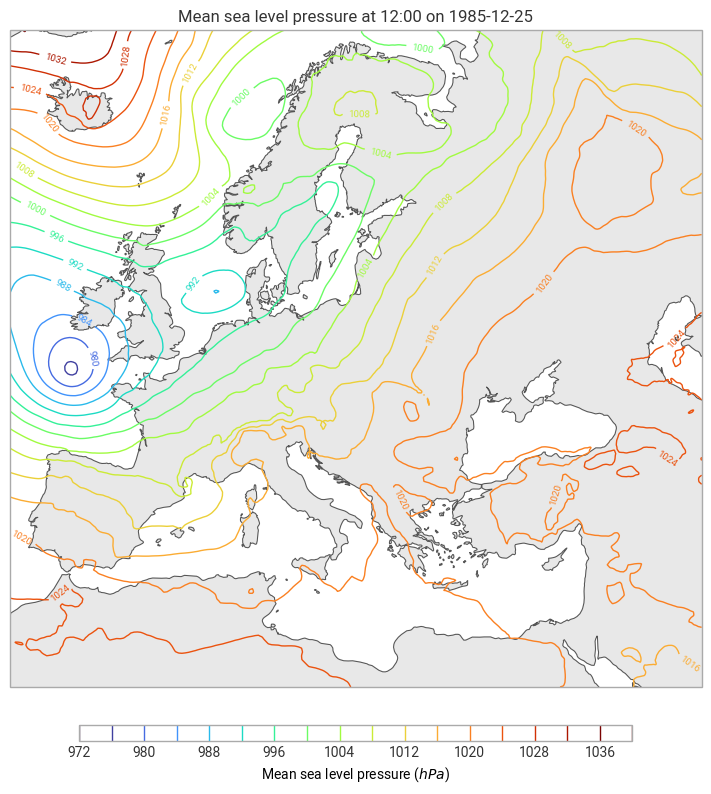

In [5]:
# Colour-mapped version
turbo_style = ekp.styles.Contour(
    units="hPa",
    levels={"step": 4, "reference": 1000},
    colors="turbo",
    linewidths=1,
    labels=True,
)

chart = ekp.Map(domain="Europe")
chart.contour(pressure, style=turbo_style)
chart.legend()
chart.land()
chart.coastlines()
chart.title()
chart.show()

### Combining two styles on one map

Define styles for both variables and layer them:

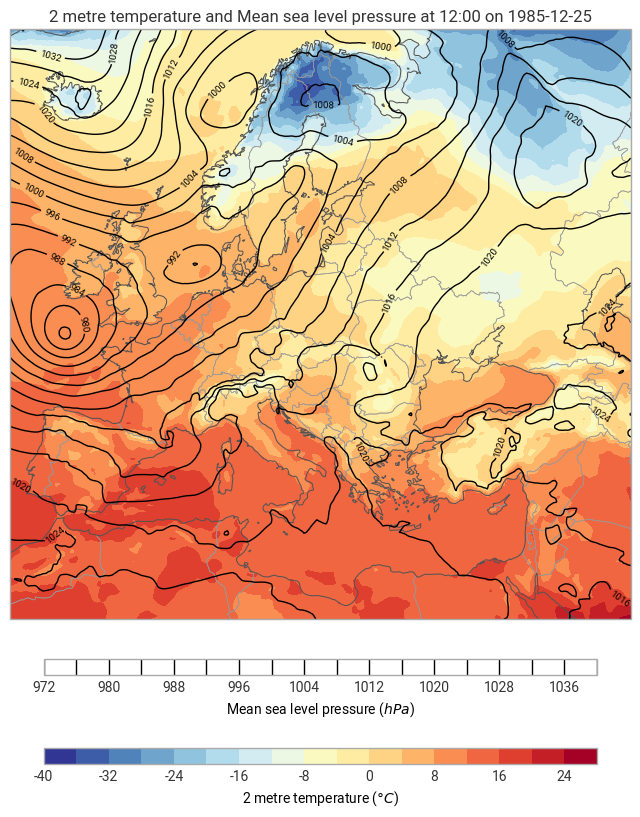

In [6]:
t2m_style = ekp.styles.Style(
    units="celsius",
    colors="RdYlBu_r",
    levels={"step": 4, "reference": 0},
)

msl_bw = ekp.styles.Contour(
    units="hPa",
    levels={"step": 4, "reference": 1000},
    colors="black",
    linewidths=[0.6, 0.6, 0.6, 0.6, 1.4],
    linestyles=["solid", "solid", "solid", "solid", "solid"],
    labels=True,
)

chart = ekp.Map(domain="Europe")
chart.contourf(temperature, style=t2m_style)
chart.contour(pressure, style=msl_bw)
chart.legend()
chart.land()
chart.borders()
chart.coastlines()
chart.title()
chart.show()